## Aim: Train an SchNET architecture
#### Purpose:
- Learn Graph-PES
- Get more familiar with the end to end training & evaluation process
- Use ASE
- Have a baseline of an invariant NN to start applying transfer techniques on it.

In [17]:
import ase.io
import pandas as pd
import numpy as np
from load_atoms import view

In [18]:
train = ase.io.read("data/train.xyz", index=":")
valid = ase.io.read("data/valid.xyz", index=":")

800 50



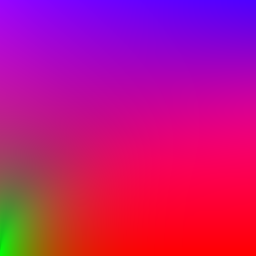

In [19]:
print(len(train), len(valid))
view(train[0])

In [44]:
atoms = train[0]
print(len(atoms))
print(atoms.get_chemical_formula())
print(atoms.positions.shape)
print(atoms.cell)
print(atoms.pbc)

144
O96Si48
(144, 3)
Cell([12.179201, 12.179201, 12.179201])
[ True  True  True]


In [45]:
forces = atoms.arrays["QM_forces"]
energy = atoms.info["QM_energy"]

print(forces)
print(energy)

[[ 1.57869e+00 -6.39000e-01  3.25330e-01]
 [-1.94740e-01  7.60700e-01  1.33180e-01]
 [ 7.00000e-04 -6.93280e-01 -6.73260e-01]
 [ 6.92100e-02 -3.87100e-02 -1.57950e-01]
 [-3.23220e-01  4.35350e-01  7.75500e-01]
 [-7.74990e-01 -1.16181e+00  2.45120e-01]
 [ 1.29180e-01  5.09830e-01  1.31925e+00]
 [ 4.14460e-01  2.37670e-01 -1.73220e-01]
 [-2.56647e+00  1.11074e+00 -9.89360e-01]
 [ 8.32220e-01  1.22350e-01  4.51610e-01]
 [ 2.54050e-01 -2.56680e-01 -1.37241e+00]
 [-3.67660e-01 -4.47920e-01  2.49050e-01]
 [-1.85609e+00 -1.70022e+00 -1.72839e+00]
 [ 3.42990e-01  2.81280e-01  1.28750e-01]
 [-2.47990e-01 -5.24720e-01 -3.24230e-01]
 [ 6.87310e-01  6.26260e-01 -2.26050e-01]
 [-5.94940e-01  1.01779e+00 -6.58500e-02]
 [-1.64560e-01 -3.66860e-01  1.97090e-01]
 [ 3.64440e-01 -4.61260e-01 -5.19700e-01]
 [ 3.71850e-01  3.27030e-01  1.15010e-01]
 [-1.59726e+00  6.36860e-01 -1.02542e+00]
 [ 5.89370e-01  5.34090e-01  3.36090e-01]
 [ 1.10755e+00 -1.39300e-02 -9.34870e-01]
 [ 8.98200e-01  1.70172e+00  1.749

In [46]:
energy_per_atom = energy / len(atoms)
forces_magnitude = np.linalg.norm(forces, axis=1)

print(energy_per_atom)
print(forces_magnitude)
print(forces_magnitude.shape)
print(forces_magnitude.max())

-351.0641815416667
[1.7339039  0.79644527 0.96639364 0.17673905 0.94625633 1.41791953
 1.42022346 0.50820202 2.96636896 0.95473098 1.41913186 0.63073933
 3.05338339 0.46188434 0.66479712 0.95691966 1.18075667 0.44778424
 0.78464348 0.50837815 2.00207801 0.86346141 1.4494285  1.93215739
 0.80629249 0.7722666  1.0893691  0.79539178 0.79890002 0.93332142
 1.40874613 0.26687841 0.98138405 1.45985084 1.2002383  0.53647107
 0.40596796 0.56227798 1.90818884 0.90613629 1.55173685 0.50902215
 1.60605715 0.52308625 1.14856728 0.54033672 0.5775515  0.40799337
 1.16381822 1.46169109 1.33662182 1.7776624  2.04416742 1.31727329
 0.85151963 2.11697917 1.40450043 0.70399561 1.72190067 0.94002437
 0.99157211 1.99402208 1.56354898 1.34851831 1.17048148 0.59207926
 1.68213901 3.02263608 0.8399039  0.44140653 0.82067039 1.85504886
 1.15302267 1.05971012 0.93908481 0.77102304 1.75426261 0.85275015
 2.08555028 0.31050691 1.2009696  1.31350827 0.88899163 2.55127853
 0.82256258 2.3920245  2.64960748 0.6878844

In [50]:
rows = []

# Also add: structure index, atom count, chemical formula, total energy, add a split column containing "train"

for atoms in train:
    energy = atoms.info["QM_energy"]
    forces = atoms.arrays["QM_forces"]
    energy_per_atom = energy / len(atoms)
    forces_magnitude = np.linalg.norm(forces, axis=1)
    rows.append((energy, energy_per_atom, forces_magnitude.max()))



print(rows)
df = pd.DataFrame(rows, columns=["total_energy", "energy_per_atom", "max_forces_magnitude"])

df.head()

[(np.float64(-50553.242142), np.float64(-351.0641815416667), np.float64(3.1786139786076575)), (np.float64(-50548.698048), np.float64(-351.0326253333333), np.float64(3.8618344079595133)), (np.float64(-50553.219252), np.float64(-351.0640225833333), np.float64(4.383593885774548)), (np.float64(-50518.158131), np.float64(-350.82054257638885), np.float64(18.01687018260941)), (np.float64(-50523.999851), np.float64(-350.8611100763889), np.float64(9.976230931534214)), (np.float64(-50555.798274), np.float64(-351.0819324583333), np.float64(4.602261364449003)), (np.float64(-50517.895832), np.float64(-350.81872105555556), np.float64(10.13309428134368)), (np.float64(-50554.362265), np.float64(-351.07196017361116), np.float64(3.1592892153774086)), (np.float64(-50554.995166), np.float64(-351.0763553194445), np.float64(3.395534788232923)), (np.float64(-50542.228565), np.float64(-350.98769836805553), np.float64(8.674612514608361)), (np.float64(-50552.575497), np.float64(-351.05955206249996), np.float64(

,total_energy,energy_per_atom,max_forces_magnitude
0,-50553.242142,-351.064182,3.178614
1,-50548.698048,-351.032625,3.861834
2,-50553.219252,-351.064023,4.383594
3,-50518.158131,-350.820543,18.016870
4,-50523.999851,-350.861110,9.976231


In [52]:
print(df.describe())
print(df.isna().sum())


       total_energy  energy_per_atom  max_forces_magnitude
count    800.000000       800.000000            800.000000
mean  -50546.781431      -351.019315              5.611262
std       14.541190         0.100980              3.178847
min   -50560.326585      -351.113379              2.207690
25%   -50555.467822      -351.079638              3.687860
50%   -50553.230697      -351.064102              4.131050
75%   -50546.515774      -351.017471              6.223561
max   -50491.906434      -350.638239             22.487876
total_energy            0
energy_per_atom         0
max_forces_magnitude    0
dtype: int64


In [63]:
from graph_pes import AtomicGraph

graph = AtomicGraph.from_ase(
    train[0],
    cutoff=5.0,
    property_mapping={"QM_energy": "energy", "QM_forces" : "forces"}
)

In [64]:
print(graph.Z)
print(graph.R.shape)
print(graph.neighbour_list.shape)
print(graph.properties)

tensor([ 8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
         8,  8,  8,  8,  8,  8, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14])
torch.Size([144, 3])
torch.Size([2, 6070])
{'energy': tensor(-50553.2422), 'forces': tensor([[ 1.5787e+00, -6.3900e-01,  3.2533e-01],
        [-1.9474e-01,  7.6070e-01,  1.3318e-01],
        [ 7.0000e-04, -6.9328e-01, -6.7326e-01],
        [ 6.9210e-02, -3.8710e-02, -1.5795e-01],
        [-3.2322e-01,  4.3535e-01,  7.7550e-01],
        [-7.7499e-01, -1.1618

### Settings:
Cutoff : 5.0Å
Layers : 3
Channels : 64
Expansion Features : 50

In [65]:
import yaml

with open("train.yaml") as file:
    config = yaml.safe_load(file)

config["model"]

{'offset': {'+FixedOffset': {'Si': -1053.057946470156, 'O': 0.0}},
 'schnet': {'+SchNet': {'cutoff': '=/CUTOFF',
   'layers': 3,
   'channels': 64,
   'expansion_features': 50}}}

### Loss settings
We have per atom energy loss, and force RMSE, weighted at 1:5.

In [67]:
import sys
import subprocess

print(sys.executable)

/Users/louismcauliffe/code/research/SchNET-baseline/.venv/bin/python


In [68]:
command = [
    sys.executable, "-m", "graph_pes.scripts.train",
    "train.yaml",
    "general/run_id=local-check",
    "data/train/n=8",
    "data/valid/n=8",
    "fitting/trainer_kwargs/accelerator=cpu",
    "fitting/trainer_kwargs/devices=1",
    "fitting/trainer_kwargs/max_epochs=1",
    "wandb=null",
]

In [69]:
result = subprocess.run(command, check = True)

[graph-pes INFO]: Started `graph-pes-train` at 2026-10-05 15:40:11.542
[graph-pes INFO]: Successfully parsed config.
[graph-pes INFO]: Logging to graph-pes-results/local-check/rank-0.log
[graph-pes INFO]: ID for this training run: local-check
[graph-pes INFO]: 
Output for this training run can be found at:
    └─ graph-pes-results/local-check
        ├─ rank-0.log         # find a verbose log here
        ├─ model.pt           # the best model (according to valid/loss/total)
        ├─ lammps_model.pt    # the best model deployed to LAMMPS
        ├─ train-config.yaml  # the complete config used for this run
        └─ summary.yaml       # the summary of the training run



GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


[graph-pes INFO]: Preparing data
[graph-pes INFO]: Caching neighbour lists for 8 structures with cutoff 5.0, property mapping {'QM_energy': 'energy', 'QM_forces': 'forces'} and torch dtype torch.float32
[graph-pes INFO]: Caching neighbour lists for 8 structures with cutoff 5.0, property mapping {'QM_energy': 'energy', 'QM_forces': 'forces'} and torch dtype torch.float32
[graph-pes INFO]: Setting up datasets
[graph-pes INFO]: Pre-fitting the model on 8 samples
[graph-pes WARNING]: 
We are attempting to guess the mean per-element
contribution for a per-structure quantity (usually
the total energy). 

However, the composition of the training set is such that 
no unique solution is possible. 

This is probably because you are training on structures
all with the same composition (e.g. all structures are
of the form n H2O). Consider explicitly setting the
per-element contributions if you know them, or
including a variety of structures of different
compositions in the training set.

[graph-pe

/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the tra

                            valid/metrics         valid/metrics   valid/metrics   valid/metrics   valid/metrics   valid/metrics   timer/its_per_s   timer/its_per_s
   epoch      time   per_atom_energy_rmse   per_atom_energy_mae     energy_rmse      energy_mae     forces_rmse      forces_mae             train             valid
       1       0.3                0.13642               0.13391        19.64509        19.28320         1.25463         0.85318           8.69565          24.02746
[graph-pes INFO]: Loading best weights from "/Users/louismcauliffe/code/research/SchNET-baseline/graph-pes-results/local-check/checkpoints/best.ckpt"
[graph-pes INFO]: Training complete.
[graph-pes INFO]: Testing best model...
Testing DataLoader 1:  50%|█████     | 1/2 [00:00<00:00, 25.64it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/louismcauliffe/code/research/SchNET-baseline/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 1: 100%|██████████| 2/2 [00:00<00:00, 24.02it/s]
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃       Test metric       ┃       DataLoader 0       ┃      DataLoader 1       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test/train/energy_mae  │      15.22119140625      │                         │
│ test/train/energy_rmse  │    16.42974853515625     │                         │
│  test/train/forces_mae  │    0.9921373724937439    │                         │
│ test/train/forces_rmse  │    1.4120407104492188    │                         │
│ test/train/forces_rmse… │    1.4106144905090332    │                         │
│ test/train/per_atom_en… │   0.10570144653320312    │                         │
│ test/train/per_atom_en… │   0.11409822851419449    │                         │
│  test/valid/energy_mae  │                          │      19.283203125       │
│ test/valid/energy_rmse  │              